<a href="https://colab.research.google.com/github/roberthsu2003/machine_learning/blob/main/%E6%A9%9F%E5%99%A8%E5%AD%B8%E7%BF%92%E5%B8%B8%E4%BD%BF%E7%94%A8%E7%9A%84%E5%9C%96%E8%A1%A8/residual_plot_%E6%AE%98%E5%B7%AE%E5%9C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 迴歸診斷：殘差圖 (Residual Plot)

在線性迴歸 (Linear Regression) 中，**殘差圖**是評估模型假設與擬合效果最重要的診斷工具。
- **殘差 (Residual)** 的定義：$e_i = y_i - \hat{y}_i$（實際值減去預測值）。
- **優秀的線性擬合**：殘差應該**隨機且均勻地**分佈在 $y = 0$ 的水平線上下，呈現一個無規律的點雲，這代表誤差項符合獨立且變異數同質的假設。
- **不佳的線性擬合**：如果殘差圖中出現特定的**幾何圖案或趨勢**（例如拋物線/U型、漏斗型），代表數據中存在模型未能捕捉到的非線性關係，或是誤差項變異數隨自變數增加而改變（異質變異數）。

本篇將使用 `Scikit-Learn` 訓練線性迴歸模型，並繪製殘差圖進行診斷。

## 1. 環境設定與下載中文字型

In [2]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=c4ae975a05d3f41329ed8c2c7951f4e43ab1dbed051bb2f9ae0b805c543381fb
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [3]:
# 下載中文字型
import os
import wget

if not os.path.exists("ChineseFont.ttf"):
    wget.download("https://github.com/roberthsu2003/machine_learning/raw/refs/heads/main/source_data/ChineseFont.ttf")

In [4]:
# 設定 Matplotlib 使用下載的中文字型
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.font_manager import fontManager

fontManager.addfont("ChineseFont.ttf")
mpl.rc('font', family="ChineseFont")
mpl.rcParams['axes.unicode_minus'] = False  # 正常顯示負號

## 2. 建立示範數據與模型訓練
我們模擬兩種場景：
1. **場景 A (合適的線性擬合)**：真實關係為線性，加上常態分佈雜訊。
2. **場景 B (欠擬合/非線性遺漏)**：真實關係為二次曲線 (Quadratic)，但我們仍使用簡單線性模型去擬合它。

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression

np.random.seed(42)
X = np.random.uniform(-3, 3, (150, 1))

# 場景 A：線性關係
y_linear = 2 * X.squeeze() + np.random.normal(0, 1.5, size=150)
model_A = LinearRegression()
model_A.fit(X, y_linear)
pred_A = model_A.predict(X)
residuals_A = y_linear - pred_A

# 場景 B：二次曲線非線性關係 (X^2)
y_nonlinear = 1.5 * (X.squeeze()**2) + np.random.normal(0, 1.5, size=150)
model_B = LinearRegression()
model_B.fit(X, y_nonlinear)
pred_B = model_B.predict(X)
residuals_B = y_nonlinear - pred_B

## 3. 繪製殘差圖進行對比
我們在同一個畫布中繪製對比圖，觀察合適與不合適擬合的殘差差異。

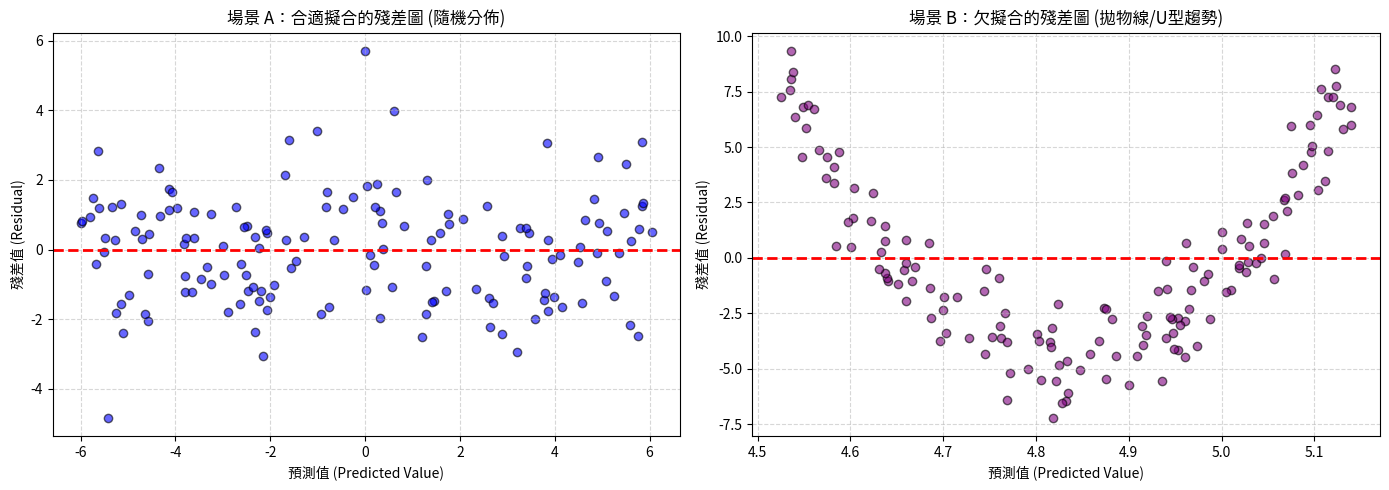

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------- 左圖：場景 A (無規律點雲) -----------------
axes[0].scatter(pred_A, residuals_A, color='blue', alpha=0.6, edgecolors='k')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title("場景 A：合適擬合的殘差圖 (隨機分佈)", fontsize=12)
axes[0].set_xlabel("預測值 (Predicted Value)", fontsize=10)
axes[0].set_ylabel("殘差值 (Residual)", fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.5)

# ----------------- 右圖：場景 B (具備規律的 U 型圖案) -----------------
axes[1].scatter(pred_B, residuals_B, color='purple', alpha=0.6, edgecolors='k')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("場景 B：欠擬合的殘差圖 (拋物線/U型趨勢)", fontsize=12)
axes[1].set_xlabel("預測值 (Predicted Value)", fontsize=10)
axes[1].set_ylabel("殘差值 (Residual)", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 結論分析
- **場景 A 殘差圖**：殘差均勻、隨機地散佈在紅線 ($y=0$) 上下，表明線性模型的假設完全成立。
- **場景 B 殘差圖**：殘差呈現出明顯的 **U型拋物線模式**。這是一個強烈信號，表明當前模型遺漏了非線性特徵（如自變數的二次項 $X^2$）。此時我們應考慮引入多項式特徵 (Polynomial Features) 或使用非線性模型。